# 01 · How a pick is made - one match, end to end

In this pool you predict the **exact scoreline**. Scoring is asymmetric:

| Outcome | Points |
|---|---|
| Exact score | **4** |
| Right winner **and** goal difference | **3** |
| Right winner only | **2** |
| Wrong | **0** |

There is **no goal-difference tier for a draw**. That skew means the score that
*maximises expected points* is usually **not** the most likely score. Let's watch
that happen on one synthetic match, from market odds to the final pick.

In [1]:
%matplotlib inline
import logging, numpy as np, matplotlib.pyplot as plt
logging.getLogger("src.odds.reconstruct").setLevel(logging.ERROR)  # quiet fit-warnings
from src.odds.devig import devig_1x2, devig_over_under, overround
from src.odds.reconstruct import reconstruct_matrix
from src.scoring.kicktipp import optimal_prediction, ev_table, expected_points

## 1. The market odds (synthetic)

A moderate home favourite. Decimal odds carry a bookmaker margin - the *overround*.

In [2]:
home_odds, draw_odds, away_odds = 1.80, 3.60, 4.50
over_odds, under_odds = 1.95, 1.85
print(f"1X2 overround: {overround([home_odds, draw_odds, away_odds])*100:.1f}%  (the book's margin)")

1X2 overround: 5.6%  (the book's margin)


## 2. De-vig -> fair probabilities

Remove the margin (here with Shin's method) to recover fair probabilities that sum to 1.

In [3]:
p_home, p_draw, p_away = devig_1x2(home_odds, draw_odds, away_odds, method="shin")
p_over, p_under = devig_over_under(over_odds, under_odds, method="shin")
print(f"fair P(home win) = {p_home:.3f}")
print(f"fair P(draw)     = {p_draw:.3f}")
print(f"fair P(away win) = {p_away:.3f}")
print(f"fair P(over 2.5) = {p_over:.3f}")

fair P(home win) = 0.534
fair P(draw)     = 0.260
fair P(away win) = 0.205
fair P(over 2.5) = 0.486


## 3. Build the score matrix (Dixon-Coles)

Reconstruct the scoring rates and a full **P(home goals, away goals)** matrix - a
double-Poisson with a low-score correlation correction.

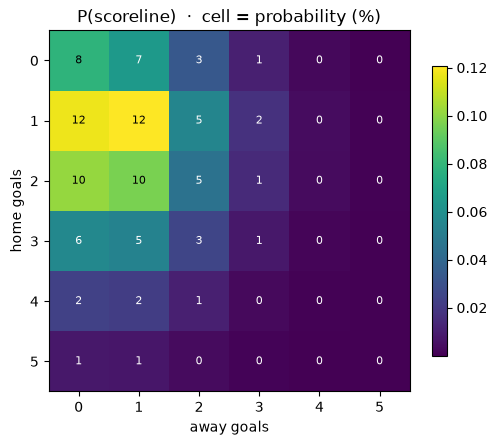

In [4]:
M = reconstruct_matrix(p_home, p_draw, p_away, p_over)
G = 5
grid = M[:G+1, :G+1]
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(grid, cmap="viridis", origin="upper")
for i in range(G+1):
    for j in range(G+1):
        ax.text(j, i, f"{grid[i,j]*100:.0f}", ha="center", va="center",
                color="white" if grid[i,j] < grid.max()*0.55 else "black", fontsize=8)
ax.set_xticks(range(G+1)); ax.set_yticks(range(G+1))
ax.set_xlabel("away goals"); ax.set_ylabel("home goals")
ax.set_title("P(scoreline)  ·  cell = probability (%)")
fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

## 4. Most likely score vs EV-max pick

The single most likely score is the matrix argmax. But we're scored on expected
**points**, not probability - so compute `E[points]` for every candidate scoreline.

most-likely score : 1-1   P=0.121   E[points]=0.748
EV-MAX pick       : 1-0   E[points]=1.433


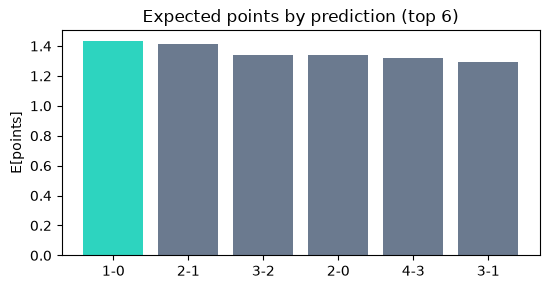

In [5]:
i, j = np.unravel_index(np.argmax(M), M.shape)
naive = (int(i), int(j))
best, best_ev = optimal_prediction(M)

print(f"most-likely score : {naive[0]}-{naive[1]}   "
      f"P={M[i,j]:.3f}   E[points]={expected_points(naive, M):.3f}")
print(f"EV-MAX pick       : {best[0]}-{best[1]}   E[points]={best_ev:.3f}")

cands = sorted(((expected_points((a,b),M),(a,b)) for a in range(5) for b in range(5)),
               reverse=True)[:6]
labels = [f"{a}-{b}" for _,(a,b) in cands]; vals = [ev for ev,_ in cands]
plt.figure(figsize=(5.6,3))
plt.bar(labels, vals, color=["#2dd4bf" if (a,b)==best else "#6b7a8f" for _,(a,b) in cands])
plt.ylabel("E[points]"); plt.title("Expected points by prediction (top 6)")
plt.tight_layout(); plt.show()

### Takeaway

The most likely single score here is **1-1** - a *draw* - yet its expected value is
low, because a drawn prediction can only ever hit the 4-pt exact or the 2-pt tendency:
**the 3-pt goal-difference tier is unreachable for draws.** The EV-max pick is
**1-0**, which harvests the exact, goal-difference *and* tendency tiers across nearby
outcomes - nearly **doubling** the expected points of the modal score.

That one asymmetry - *safe, favourite-leaning scorelines beat the modal score* - is the
engine's edge on the scoreline itself. Notebook 02 shows the flip side: what it costs
opponents to ignore it.